In [1]:
# Librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Cargamos el archivo CSV

Bitacora = pd.read_csv("Analisis GAC Full7agosto 2026(Bitacora de Piso).csv")

In [3]:
Bitacora.head()

,Fecha,Nombre Cliente,Telefono,Asesor,Esatus Lead,PDM,SDC,Estatus de SDC,Venta,Temperatura,...,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29
0,04/01/2025,Ubaldo Cruz Hernandez,NaN,Aurelio,Activo,True,False,NaN,False,Lead InteresBajo,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,04/01/2025,Olivia Cabello,NaN,Pedro,Activo,False,False,NaN,False,Lead InteresBajo,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,04/02/2025,Ana Laura Espinoza,NaN,Mauricio,Activo,True,True,Analisis,True,Lead Interes Alto,...,NaN,NaN,NaN,NaN,NaN,NaN,Items,Items,items,items
3,04/02/2025,Elvis Sanchez,NaN,Aurelio,Activo,False,False,NaN,False,Lead InteresBajo,...,NaN,NaN,NaN,NaN,NaN,NaN,Aurelio,Activo,Aprobada,Lead Interes Medio
4,04/03/2025,Ariel Fernando López,NaN,Alan,Activo,True,False,NaN,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Pedro,Cerrado,Condicionada,Lead InteresBajo


In [4]:
Bitacora.info()

<class 'pandas.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 30 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Fecha                                       198 non-null    str    
 1   Nombre Cliente                              197 non-null    str    
 2   Telefono                                    0 non-null      float64
 3   Asesor                                      196 non-null    str    
 4   Esatus Lead                                 197 non-null    str    
 5   PDM                                         234 non-null    bool   
 6   SDC                                         216 non-null    object 
 7   Estatus de SDC                              2 non-null      str    
 8   Venta                                       216 non-null    object 
 9   Temperatura                                 10 non-null     str    
 10  Inter Gerente            

In [5]:
# Eliminamos filas que no tienen fecha

Bitacora = Bitacora.dropna(subset=["Fecha"])


# Eliminamos columnas que están completamente vacías

Bitacora = Bitacora.dropna(axis=1, how="all")


# Reiniciamos el índice

Bitacora = Bitacora.reset_index(drop=True)

In [6]:
Bitacora.info()

<class 'pandas.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 21 columns):
 #   Column                                      Non-Null Count  Dtype 
---  ------                                      --------------  ----- 
 0   Fecha                                       198 non-null    str   
 1   Nombre Cliente                              197 non-null    str   
 2   Asesor                                      196 non-null    str   
 3   Esatus Lead                                 197 non-null    str   
 4   PDM                                         198 non-null    bool  
 5   SDC                                         198 non-null    object
 6   Estatus de SDC                              2 non-null      str   
 7   Venta                                       198 non-null    object
 8   Temperatura                                 10 non-null     str   
 9   Inter Gerente                               198 non-null    object
 10  ¿Por que no hubo prueba de manejo?   

In [7]:
# Eliminamos espacios de los nombres de las columnas

Bitacora.columns = Bitacora.columns.str.strip()


# Corregimos el nombre de la columna

Bitacora = Bitacora.rename(columns={"Esatus Lead": "Estatus Lead"})

In [8]:
# Mostramos los nombres de las columnas

Bitacora.columns

Index(['Fecha', 'Nombre Cliente', 'Asesor', 'Estatus Lead', 'PDM', 'SDC',
       'Estatus de SDC', 'Venta', 'Temperatura', 'Inter Gerente',
       '¿Por que no hubo prueba de manejo?',
       '¿Por que no hubo Solicitud de credito?',
       '¿Por que no hubo intervencion del Gerente?',
       '¿Por que no hubo proceso wow?',
       '¿Por que no se ha formalizado la compra?',
       '5 porques clientes de piso', 'Comentarios', 'Unnamed: 26',
       'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29'],
      dtype='str')

In [9]:
# Eliminamos espacios sobrantes en las columnas de texto

columnas_texto = ["Asesor", "Estatus Lead", "Estatus de SDC", "Temperatura"]

for columna in columnas_texto:
    Bitacora[columna] = Bitacora[columna].str.strip()

In [10]:
# Unificamos las categorías del estatus del lead

Bitacora["Estatus Lead"] = Bitacora["Estatus Lead"].str.title()

In [11]:
# Sustituimos los valores nulos por una categoría

Bitacora["Asesor"] = Bitacora["Asesor"].fillna("No registrado")
Bitacora["Estatus Lead"] = Bitacora["Estatus Lead"].fillna("No registrado")
Bitacora["Estatus de SDC"] = Bitacora["Estatus de SDC"].fillna("No aplica")
Bitacora["Temperatura"] = Bitacora["Temperatura"].fillna("No registrado")

In [12]:
# Convertimos la columna Fecha a formato de fecha
# Convertimos la columna Fecha a formato de fecha

Bitacora["Fecha"] = pd.to_datetime(Bitacora["Fecha"], format="%m/%d/%Y", errors="coerce")


# Creamos las variables Mes y Día de la semana

Bitacora["Mes"] = Bitacora["Fecha"].dt.month_name()
Bitacora["Dia Semana"] = Bitacora["Fecha"].dt.day_name()

In [13]:
# Mostramos las nuevas variables

Bitacora[["Fecha", "Mes", "Dia Semana"]].head()

,Fecha,Mes,Dia Semana
0,2025-04-01,April,Tuesday
1,2025-04-01,April,Tuesday
2,2025-04-02,April,Wednesday
3,2025-04-02,April,Wednesday
4,2025-04-03,April,Thursday


In [14]:
# Cantidad final de filas y columnas

print("Dimensiones:", Bitacora.shape)

Dimensiones: (198, 23)


In [15]:
# Valores nulos de las variables que analizaremos

Bitacora[["Asesor", "Estatus Lead", "PDM", "SDC", "Estatus de SDC", "Venta", "Temperatura", "Inter Gerente", "Mes", "Dia Semana"]].isnull().sum()

Asesor            0
Estatus Lead      0
PDM               0
SDC               0
Estatus de SDC    0
Venta             0
Temperatura       0
Inter Gerente     0
Mes               0
Dia Semana        0
dtype: int64

In [16]:
# Obtenemos la frecuencia de cada asesor

Tabla_Asesor = Bitacora["Asesor"].value_counts().reset_index()
Tabla_Asesor

,Asesor,count
0,Aurelio,34
1,Mauricio,28
2,Pedro,25
3,Victor,20
4,Alan,14
5,Aurelio Torres,13
6,Pedro González,11
7,Ricardo,10
8,Alan González,9
9,Mauricio Vazquez,6


In [17]:
# Filtramos los asesores con frecuencia mayor a 1

Filtro_Asesor = Tabla_Asesor[Tabla_Asesor["count"] > 1]
Filtro_Asesor

,Asesor,count
0,Aurelio,34
1,Mauricio,28
2,Pedro,25
3,Victor,20
4,Alan,14
5,Aurelio Torres,13
6,Pedro González,11
7,Ricardo,10
8,Alan González,9
9,Mauricio Vazquez,6


In [18]:
# Colocamos los nombres de los asesores como índice

Filtro_Asesor_index = Filtro_Asesor.set_index("Asesor")
Filtro_Asesor_index

,count
Asesor,
Aurelio,34
Mauricio,28
Pedro,25
Victor,20
Alan,14
Aurelio Torres,13
Pedro González,11
Ricardo,10
Alan González,9


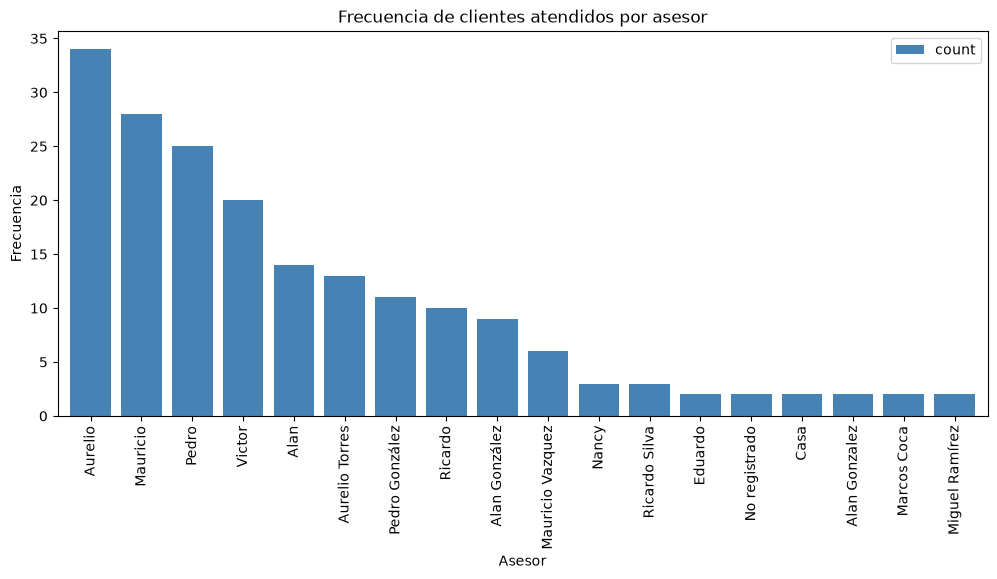

In [19]:
# Gráfica 1: Asesores

Filtro_Asesor_index.plot(kind="bar", width=0.8, figsize=(12,5), color="steelblue")

plt.title("Frecuencia de clientes atendidos por asesor")
plt.xlabel("Asesor")
plt.ylabel("Frecuencia")
plt.xticks(rotation=90)
plt.show()

In [20]:
Tabla_Estatus = Bitacora["Estatus Lead"].value_counts().reset_index()
Filtro_Estatus = Tabla_Estatus[Tabla_Estatus["count"] > 0]
Filtro_Estatus_index = Filtro_Estatus.set_index("Estatus Lead")

Filtro_Estatus

,Estatus Lead,count
0,Activo,168
1,Cerrado,18
2,Venta,7
3,Finalizado,4
4,No registrado,1


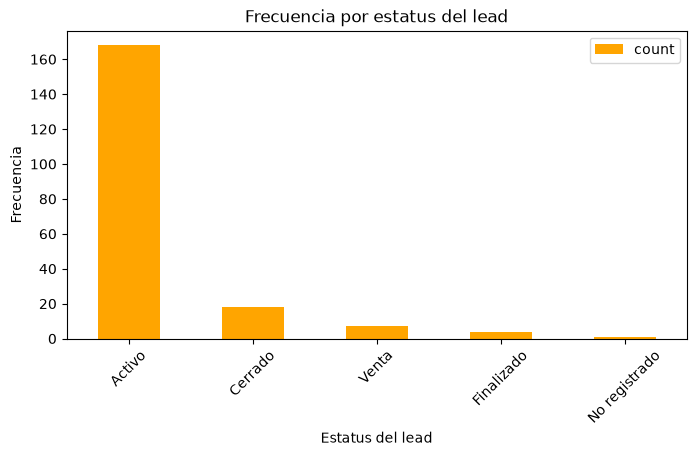

In [21]:
# Gráfica 2: Estatus Lead

Filtro_Estatus_index.plot(kind="bar", figsize=(8,4), color="orange")

plt.title("Frecuencia por estatus del lead")
plt.xlabel("Estatus del lead")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.show()

In [22]:
Tabla_PDM = Bitacora["PDM"].value_counts().reset_index()
Filtro_PDM = Tabla_PDM[Tabla_PDM["count"] > 0]
Filtro_PDM_index = Filtro_PDM.set_index("PDM")

Filtro_PDM

,PDM,count
0,False,123
1,True,75


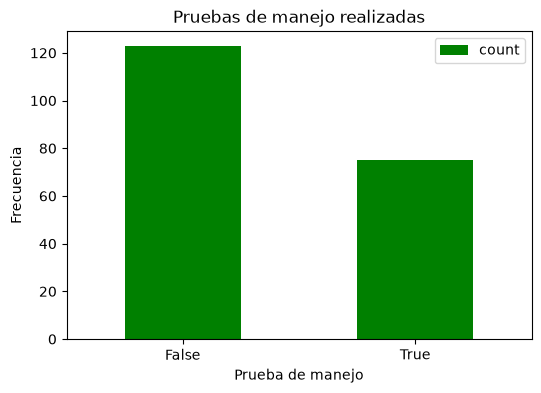

In [23]:
# Gráfica 3: Prueba de manejo

Filtro_PDM_index.plot(kind="bar", figsize=(6,4), color="green")

plt.title("Pruebas de manejo realizadas")
plt.xlabel("Prueba de manejo")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)
plt.show()

In [24]:
Tabla_SDC = Bitacora["SDC"].value_counts().reset_index()
Filtro_SDC = Tabla_SDC[Tabla_SDC["count"] > 0]
Filtro_SDC_index = Filtro_SDC.set_index("SDC")

Filtro_SDC

,SDC,count
0,False,194
1,True,4


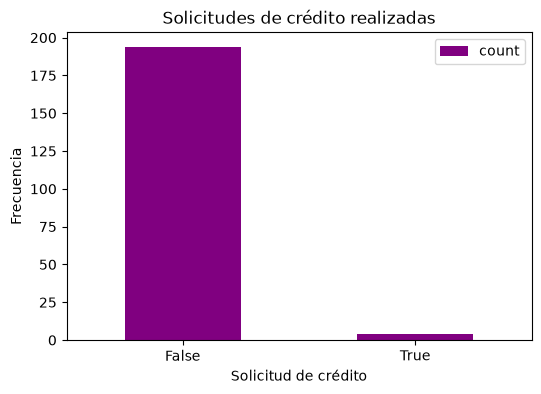

In [25]:
# Gráfico 4: Solicitud de crédito

Filtro_SDC_index.plot(kind="bar", figsize=(6,4), color="purple")

plt.title("Solicitudes de crédito realizadas")
plt.xlabel("Solicitud de crédito")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)
plt.show()

In [26]:
Tabla_Estatus_SDC = Bitacora["Estatus de SDC"].value_counts().reset_index()
Filtro_Estatus_SDC = Tabla_Estatus_SDC[Tabla_Estatus_SDC["count"] > 0]
Filtro_Estatus_SDC_index = Filtro_Estatus_SDC.set_index("Estatus de SDC")

Filtro_Estatus_SDC_index

,count
Estatus de SDC,
No aplica,196
Analisis,1
Rechazada,1


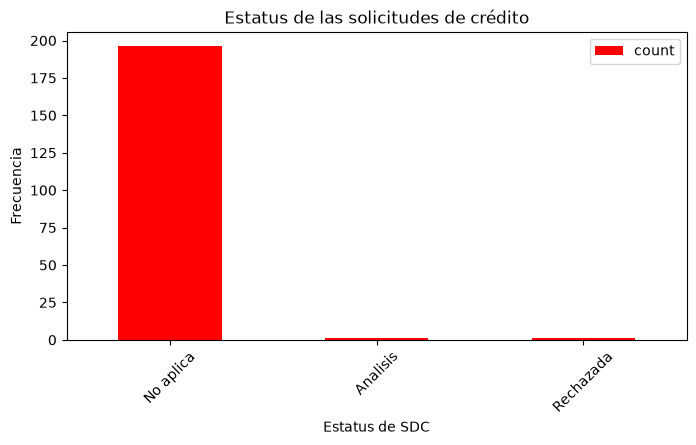

In [27]:
# Gráfico 5: Estatus de solicitud de crédito

Filtro_Estatus_SDC_index.plot(kind="bar", figsize=(8,4), color="red")

plt.title("Estatus de las solicitudes de crédito")
plt.xlabel("Estatus de SDC")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.show()

In [28]:
Tabla_Venta = Bitacora["Venta"].value_counts().reset_index()
Filtro_Venta = Tabla_Venta[Tabla_Venta["count"] > 0]
Filtro_Venta_index = Filtro_Venta.set_index("Venta")

Filtro_Venta_index

,count
Venta,
False,194
True,4


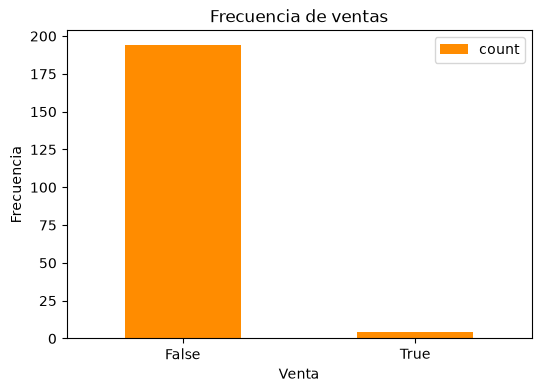

In [29]:
# Gráfico 6: Ventas

Filtro_Venta_index.plot(kind="bar", figsize=(6,4), color="darkorange")

plt.title("Frecuencia de ventas")
plt.xlabel("Venta")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)
plt.show()

In [30]:
Tabla_Temperatura = Bitacora["Temperatura"].value_counts().reset_index()
Filtro_Temperatura = Tabla_Temperatura[Tabla_Temperatura["count"] > 0]
Filtro_Temperatura_index = Filtro_Temperatura.set_index("Temperatura")

Filtro_Temperatura_index

,count
Temperatura,
No registrado,188
Lead InteresBajo,4
Lead Interes Alto,3
Lead Interes Medio,1
Ebullición,1
Tibio,1


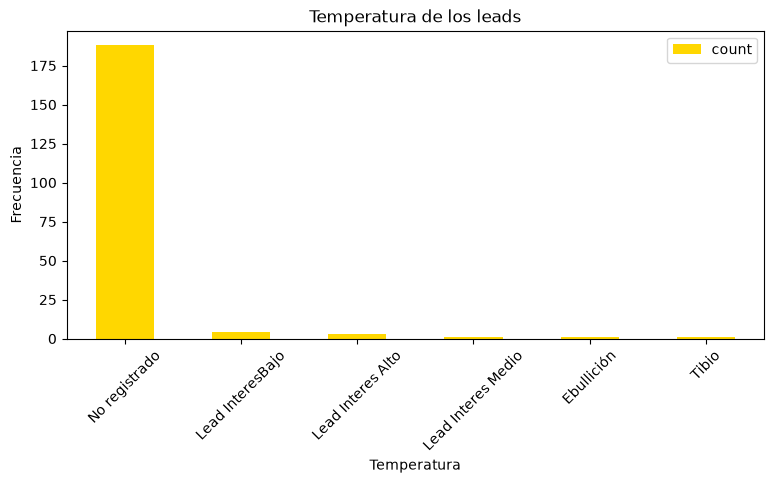

In [31]:
# Gráfico 7: Temperatura

Filtro_Temperatura_index.plot(kind="bar", figsize=(9,4), color="gold")

plt.title("Temperatura de los leads")
plt.xlabel("Temperatura")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.show()

In [32]:
Tabla_Gerente = Bitacora["Inter Gerente"].value_counts().reset_index()
Filtro_Gerente = Tabla_Gerente[Tabla_Gerente["count"] > 0]
Filtro_Gerente_index = Filtro_Gerente.set_index("Inter Gerente")

Filtro_Gerente_index

,count
Inter Gerente,
False,167
True,31


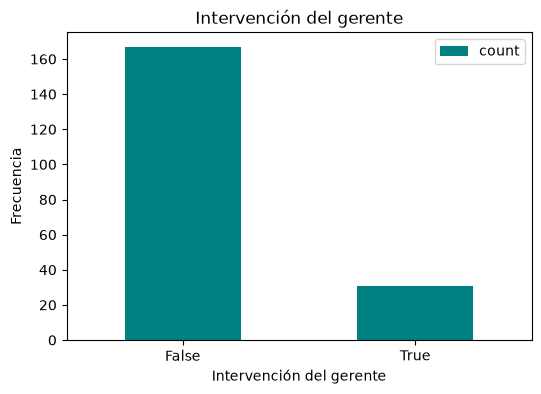

In [33]:
# Gráfico 8: Intervención del gerente

Filtro_Gerente_index.plot(kind="bar", figsize=(6,4), color="teal")

plt.title("Intervención del gerente")
plt.xlabel("Intervención del gerente")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)
plt.show()

In [34]:
Tabla_Mes = Bitacora["Mes"].value_counts().reset_index()
Filtro_Mes = Tabla_Mes[Tabla_Mes["count"] > 0]
Filtro_Mes_index = Filtro_Mes.set_index("Mes")

Filtro_Mes_index

,count
Mes,
May,65
June,59
April,46
July,27
August,1


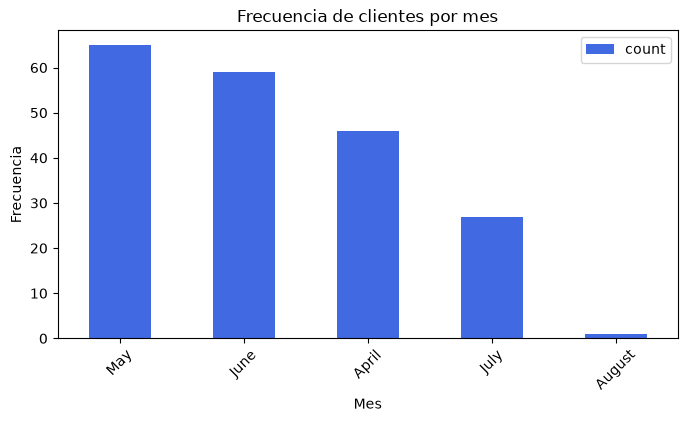

In [35]:
# Gráfico 9: Mes
Filtro_Mes_index.plot(kind="bar", figsize=(8,4), color="royalblue")

plt.title("Frecuencia de clientes por mes")
plt.xlabel("Mes")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.show()

In [36]:
Tabla_Dia = Bitacora["Dia Semana"].value_counts().reset_index()
Filtro_Dia = Tabla_Dia[Tabla_Dia["count"] > 0]
Filtro_Dia_index = Filtro_Dia.set_index("Dia Semana")

Filtro_Dia_index

,count
Dia Semana,
Friday,39
Saturday,31
Wednesday,29
Monday,29
Tuesday,26
Thursday,25
Sunday,19


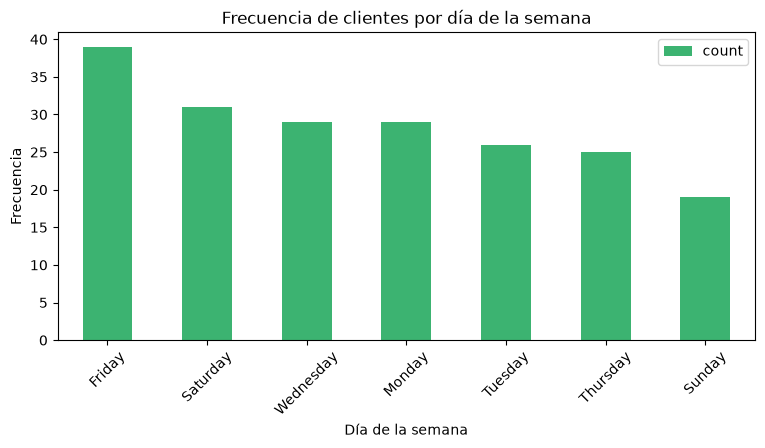

In [37]:
# Gráfico 10: Día de la semana
Filtro_Dia_index.plot(kind="bar", figsize=(9,4), color="mediumseagreen")

plt.title("Frecuencia de clientes por día de la semana")
plt.xlabel("Día de la semana")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.show()